In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score

# Load the Datasets (Google Colab Compatible)

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies","Glucose","BloodPressure","SkinThickness",
    "Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"
]

uci_diabetes = pd.read_csv(url, names=columns)
pima_diabetes = pd.read_csv(url, names=columns)

# Display first few rows
print("UCI Diabetes Dataset Sample:\n")
print(uci_diabetes.head())

print("\nPima Indians Diabetes Dataset Sample:\n")
print(pima_diabetes.head())

UCI Diabetes Dataset Sample:

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Pima Indians Diabetes Dataset Sample:

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8   


Linear Regression (Predicting BMI using Glucose):
R² Score: 0.0489


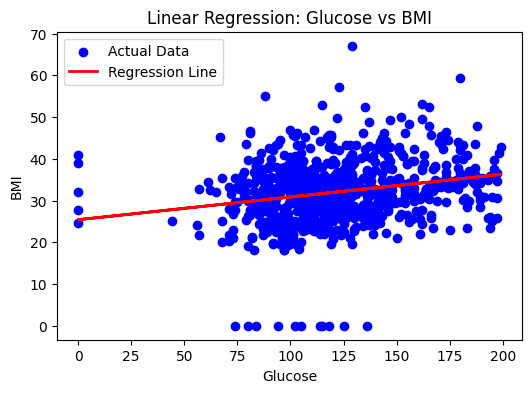


Linear Regression (Predicting BMI using Glucose):
R² Score: 0.0489


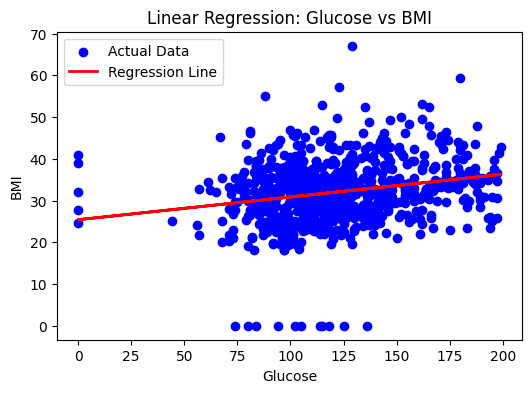

In [ ]:
# Perform Linear Regression (Glucose vs. BMI)

def linear_regression_analysis(df, x_column, y_column):

    X = df[[x_column]]      # Independent variable
    Y = df[y_column]        # Dependent variable

    model = LinearRegression()
    model.fit(X, Y)

    Y_pred = model.predict(X)

    r2 = r2_score(Y, Y_pred)

    print(f"\nLinear Regression (Predicting {y_column} using {x_column}):")
    print(f"R² Score: {r2:.4f}")

    # Plot
    plt.figure(figsize=(6,4))
    plt.scatter(X, Y, color='blue', label='Actual Data')
    plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line')

    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.title(f"Linear Regression: {x_column} vs {y_column}")
    plt.legend()
    plt.show()

# Apply Linear Regression on both datasets
linear_regression_analysis(uci_diabetes, "Glucose", "BMI")
linear_regression_analysis(pima_diabetes, "Glucose", "BMI")

In [ ]:
# Perform Logistic Regression (Predicting Diabetes)

def logistic_regression_analysis(df, features, target):

    X = df[features]
    Y = df[target]

    # Splitting dataset
    X_train, X_test, Y_train, Y_test = train_test_split(
        X,
        Y,
        test_size=0.2,
        random_state=42
    )

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)

    accuracy = accuracy_score(Y_test, Y_pred)

    print(f"\nLogistic Regression (Predicting {target} using {features}):")
    print(f"Accuracy Score: {accuracy:.4f}")

# Select features and target
features = ["Glucose", "BloodPressure", "BMI", "Age"]
target = "Outcome"

# Apply Logistic Regression on both datasets
logistic_regression_analysis(uci_diabetes, features, target)
logistic_regression_analysis(pima_diabetes, features, target)


Logistic Regression (Predicting Outcome using ['Glucose', 'BloodPressure', 'BMI', 'Age']):
Accuracy Score: 0.7403

Logistic Regression (Predicting Outcome using ['Glucose', 'BloodPressure', 'BMI', 'Age']):
Accuracy Score: 0.7403
